# Candidate Resume Search Platform — Case Study
### Data Science Case Study | Millennium BD Analyst Sourcing

**🔗 Live Streamlit app: [https://resume-search-platform-1.streamlit.app/](https://resume-search-platform-1.streamlit.app/)**

**Full submission — all phases complete:**
1. Resume parsing via LLM API → structured JSON/CSV
2. Streamlit search/filter app with visualizations — **deployed and live** ⬆️
3. Additional-features discussion & scalability notes

> **How this was produced, stated plainly:** the parsing/extraction code below (`src/`) is real, runnable Python, and the Streamlit app above is live and deployed. The build environment used to produce this notebook has **no outbound network access**, so the live Anthropic API calls could not actually be executed from inside this notebook. Where that matters, it's called out explicitly next to the relevant cell — everything else (text extraction, schema validation, data-quality checks, the charts in Section 7) *was* executed for real against the 10 sample resumes, and their outputs below are genuine, not mocked.

## 0. Install dependencies

Run this first if you're opening this notebook fresh (e.g. `Run All`) --
it installs everything in `requirements.txt` (python-docx, pdfplumber,
anthropic, pydantic, pandas, streamlit, plotly, etc.) so later cells
don't crash with `ModuleNotFoundError`.

In [ ]:
import subprocess, sys

def _pip_install():
    cmd = [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0 and "externally-managed-environment" in (result.stderr or ""):
        # Modern Debian/Ubuntu Python (PEP 668) blocks system-wide pip installs
        # by default -- retry allowing it, same as installing into a normal venv.
        result = subprocess.run(cmd + ["--break-system-packages"], capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("pip install failed -- see stderr above")

_pip_install()
print("All dependencies installed \u2014 you can now run the rest of the notebook.")

## 1. Setup

In [ ]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path('src').resolve()))

RESUME_DIR = Path('resumes') # folder containing the 10 sample resume files
OUTPUT_DIR = Path('output')  # where parsed_resumes.json / .csv get written


## 2. Text Extraction (`src/extract_text.py`)

Resumes arrive as `.pdf` and `.docx`. Several of the `.docx` files in this sample set lay out work experience as **tables** (`Organization | Duration`, `Designation | Key Role`, ...) rather than plain paragraphs — a naive paragraph-only reader silently drops most of the content. `extract_text_from_docx` explicitly walks `document.tables` as well as paragraphs to avoid that. **This cell was actually executed** against the real files.

In [ ]:
"""
extract_text.py
----------------
Phase 1 utility: pulls raw text out of resume files (.pdf / .docx) so it can
be handed to the LLM parser. Kept deliberately dependency-light (pdfplumber +
python-docx) so it runs anywhere without LibreOffice/pandoc installed --
important for "design for scalability" since this will eventually run in a
batch/serverless pipeline, not just a notebook kernel.
"""

from pathlib import Path
import sys
import docx
import pdfplumber


def extract_text_from_pdf(path: Path) -> str:
    """Concatenate text across all pages of a PDF resume."""
    chunks = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                chunks.append(page_text)
    text = "\n".join(chunks)
    if len(text.strip()) < 20:
        print(
            f"WARNING — {path.name} returned no text, this may be a scanned "
            "image PDF. Consider running OCR on this file."
        )
    return text


def extract_text_from_docx(path: Path) -> str:
    """
    Pull text from a .docx, including text sitting inside tables --
    a lot of these resumes format work-experience entries as tables
    (Organization | Duration / Designation | Key Role), so a naive
    paragraph-only read silently drops most of the content.
    """
    document = docx.Document(path)
    parts = []

    for para in document.paragraphs:
        if para.text.strip():
            parts.append(para.text)

    for table in document.tables:
        for row in table.rows:
            cells = [c.text.strip() for c in row.cells]
            deduped = []
            for c in cells:
                if c and (not deduped or c != deduped[-1]):
                    deduped.append(c)
            if deduped:
                parts.append(" | ".join(deduped))

    return "\n".join(parts)


def extract_text(path: Path) -> str:
    """Dispatch on file extension. Raises for unsupported types."""
    suffix = path.suffix.lower()
    if suffix == ".pdf":
        return extract_text_from_pdf(path)
    if suffix in (".docx", ".dotx"):
        return extract_text_from_docx(path)
    raise ValueError(f"Unsupported resume file type: {suffix} ({path.name})")


def load_all_resumes(folder: Path) -> dict[str, str]:
    """
    Read every supported resume file in `folder` and return
    {filename: raw_text}. Skips files that fail extraction but logs why,
    rather than crashing the whole batch -- at scale, a handful of corrupt
    or oddly-formatted files shouldn't take down the run.
    """
    texts = {}
    for path in sorted(folder.iterdir()):
        if path.suffix.lower() not in (".pdf", ".docx", ".dotx"):
            continue
        try:
            texts[path.name] = extract_text(path)
        except Exception as e:
            print(f"[extract_text] FAILED on {path.name}: {e}")
    return texts


if __name__ == "__main__" and "ipykernel" not in sys.modules:
    # Only run as a CLI tool (`python extract_text.py <folder>`) -- guarded against
    # firing inside Jupyter, where every cell also executes with __name__ == "__main__"
    # and sys.argv holds the kernel's own connection-file args, not a folder path.
    folder = Path(sys.argv[1]) if len(sys.argv) > 1 else Path("../")
    resumes = load_all_resumes(folder)
    for name, text in resumes.items():
        print(f"--- {name} ({len(text)} chars) ---")


In [2]:
from extract_text import load_all_resumes

resume_texts = load_all_resumes(RESUME_DIR)
for name, text in resume_texts.items():
    print(f'{name:55s} -> {len(text):5d} chars extracted')

Chen Li (Alex).docx                                    ->  4675 chars extracted
MARINA SILVA COSTA.docx                                ->  3789 chars extracted
Marcus Chen-Rodriguez Resume.docx                      ->  3459 chars extracted
Michael Rodriguez, CFA.docx                            ->  3711 chars extracted
Omar El-Hassan 202405.pdf                              ->  1604 chars extracted
Priya Nakamura_sellside_healthcare_RLTM.docx           ->  5210 chars extracted
RYAN PATEL - Resume.pdf                                ->  4953 chars extracted
Vikram Shah.docx                                       ->  4188 chars extracted
Viktor Sharat.docx                                     ->  3074 chars extracted
Zara Al-Rashid.docx                                    ->  3422 chars extracted

## 3. Structured Candidate Schema (`src/schema.py`)

Built around the BD team's stated filter dimensions (geography, investment approach, sector, experience level), plus enough supporting detail (education, certifications, employer history, skills) for a recruiter to act on a search result without re-opening the original resume. It's a Pydantic model so it doubles as:
- the JSON-schema handed to Claude as a tool definition (forces structured output)
- a validator on the way back (catches malformed/hallucinated fields)
- the single source of truth for CSV columns and the Streamlit filter widgets

In [ ]:
"""
schema.py
---------
Defines the structured record every resume gets parsed into.

Field choices map directly to the BD team's stated filter dimensions:
  - Geographic Markets:      candidate.geography
  - Investment Approach:     candidate.strategy_type
  - Sector:                  candidate.sectors (multi-value -- most people
                              cover more than one)
  - Experience Level:        candidate.total_years_experience,
                              candidate.seniority

Everything else (education, certifications, skills, employer history) is
kept because BD users will want to search/filter on it too (e.g. "CFA
holders", "ex-Goldman", "Python + ML skills" for systematic roles), and
because it's what a human recruiter would read next after the headline
filters narrow the list.

Using Pydantic gives us for free:
  - a JSON-schema we can hand to the LLM so its output is constrained
  - validation on the way back (catches hallucinated fields/types early)
  - a single source of truth for the CSV / Streamlit column list later
"""

from __future__ import annotations
from typing import Literal, Optional
from pydantic import BaseModel, Field


class Education(BaseModel):
    degree: str
    institution: str
    field_of_study: Optional[str] = None
    graduation_year: Optional[str] = None


class WorkExperience(BaseModel):
    employer: str
    title: str
    start_date: Optional[str] = None
    end_date: Optional[str] = None
    is_current: bool = False
    sectors_covered: list[str] = Field(default_factory=list)
    description: str = ""


class CandidateProfile(BaseModel):
    source_file: str
    full_name: str
    email: Optional[str] = None
    phone: Optional[str] = None
    current_location: Optional[str] = None

    geography: Literal["US", "Europe", "Asia-Pacific", "Multiple/Global"] = Field(
        description="One of: US, Europe, Asia-Pacific, Multiple/Global"
    )
    strategy_type: Literal["Fundamental", "Systematic/Quantitative", "Both", "Unclear"] = Field(
        description="One of: Fundamental, Systematic/Quantitative, Both, Unclear"
    )
    sectors: list[str] = Field(
        default_factory=list,
        description="e.g. Technology, Healthcare, Financial Services, Energy, "
                    "Industrials, Consumer, Credit, Macro, Generalist",
    )
    seniority: Literal[
        "Intern/Analyst (0-2 yrs)", "Junior (2-4 yrs)", "Mid (4-7 yrs)", "Senior (7+ yrs)"
    ] = Field(
        description="One of: Intern/Analyst (0-2 yrs), Junior (2-4 yrs), "
                    "Mid (4-7 yrs), Senior (7+ yrs)"
    )
    total_years_experience: float

    current_employer: Optional[str] = None
    current_title: Optional[str] = None

    education: list[Education] = Field(default_factory=list)
    certifications: list[str] = Field(default_factory=list)
    technical_skills: list[str] = Field(
        default_factory=list,
        description="Python, R, SQL, Bloomberg, FactSet, machine learning, C++, etc.",
    )
    languages: list[str] = Field(default_factory=list)
    work_history: list[WorkExperience] = Field(default_factory=list)
    key_achievements: list[str] = Field(
        default_factory=list,
        description="3-6 standout, quantifiable bullet points across the whole career",
    )

    parse_confidence: str = Field(
        default="high", description="high / medium / low -- LLM's own confidence flag"
    )
    parse_notes: Optional[str] = Field(
        default=None, description="Anything ambiguous the LLM flagged for human review"
    )


CANDIDATE_JSON_SCHEMA = CandidateProfile.model_json_schema()


## 4. LLM-Powered Parsing (`src/llm_parser.py`)

Each resume's raw text is sent to Claude with a system prompt tuned to this specific business context (hedge fund BD, fundamental vs. systematic, sector taxonomy, seniority bands), using **forced tool-use** so the model *must* return data matching `CandidateProfile`'s JSON schema — far more reliable than asking for JSON in prose. Failed validations are retried once with the error fed back to the model; transient API errors get exponential backoff.

In [ ]:
"""
llm_parser.py
-------------
Phase 1 core: turns raw resume text into a validated CandidateProfile using
an LLM call (Anthropic Claude). This is the piece the case study explicitly
asks for -- "Parse resume data from PDF/Word documents using LLM models via API".

Design choices, and why:
  - Structured JSON output is enforced via Claude's tool-use / forced tool-choice
    mechanism (not just "please output JSON" in the prompt). This is far more
    reliable than asking for JSON in prose and regex-extracting it.
  - The tool's input_schema is generated directly from the Pydantic model in
    schema.py, so the model and the prompt can never drift apart.
  - Every response is re-validated against the Pydantic model before being
    accepted. A parse that fails validation is retried once with the
    validation error appended to the prompt (a common, cheap way to fix
    transient LLM formatting slips) before being logged as a failure.
  - Rate limiting / retry-with-backoff is included since Phase running over
    hundreds or thousands of resumes will hit rate limits.

To run this for real: `pip install anthropic`, set ANTHROPIC_API_KEY, then
call `parse_resume_batch(...)`. Swap `MODEL` for a cheaper/faster model
if throughput matters more than accuracy at scale.
"""

from __future__ import annotations
import json
import time
from pathlib import Path
from typing import Optional

from pydantic import ValidationError

from schema import CandidateProfile, CANDIDATE_JSON_SCHEMA

MODEL = "claude-sonnet-4-6"
MAX_RETRIES = 2

SYSTEM_PROMPT = """You are a resume-parsing assistant for a hedge fund's Business \
Development team that sources junior/mid-level analyst talent across fundamental \
equity, systematic/quantitative, and credit strategies, across US, Europe, and \
Asia-Pacific markets.

Extract structured data from the resume text into the `record_candidate` tool. Rules:
- Only use information present in the resume. Never invent employers, dates, or numbers.
- geography: infer from where the candidate has worked/studied, not just their name origin.
- strategy_type: "Systematic/Quantitative" requires clear evidence (e.g. multi-factor \
models, Python/R-based backtesting, quant research roles). Sell-side/buy-side \
fundamental equity/credit research defaults to "Fundamental". Use "Both" only when \
the resume shows real split evidence, and "Unclear" when there's not enough signal.
- sectors: use the BD team's sector taxonomy (Technology, Healthcare, Financial \
Services, Energy, Industrials, Consumer, Credit, Macro) plus "Generalist" if the \
candidate covers many sectors without one clear focus.
- total_years_experience: sum full-time, post-degree work experience (exclude \
internships unless that is genuinely the person's only experience).
- key_achievements: prefer quantified bullets (%, $, bps, deal count) over vague ones.
- If something is ambiguous, still make your best-supported call, but set \
parse_confidence to "medium" or "low" and explain briefly in parse_notes.
"""

TOOL_DEFINITION = {
    "name": "record_candidate",
    "description": "Record one candidate's structured profile extracted from their resume.",
    "input_schema": CANDIDATE_JSON_SCHEMA,
}


def _build_user_message(filename: str, resume_text: str) -> str:
    return (
        f"Resume file: {filename}\n\n"
        f"--- RAW RESUME TEXT ---\n{resume_text}\n--- END RESUME TEXT ---\n\n"
        "Call record_candidate with the extracted fields."
    )


def parse_resume(filename: str, resume_text: str, client=None) -> Optional[CandidateProfile]:
    """
    Parse a single resume via the Anthropic API.
    `client` is an anthropic.Anthropic() instance, injected so this is testable
    without hitting the network, and so a single client/connection pool is
    reused across a batch instead of reconnecting per file.
    """
    import anthropic

    if client is None:
        client = anthropic.Anthropic()

    last_error = None
    raw = None
    messages = [{"role": "user", "content": _build_user_message(filename, resume_text)}]

    for attempt in range(1, MAX_RETRIES + 2):
        try:
            response = client.messages.create(
                model=MODEL,
                max_tokens=4000,
                system=SYSTEM_PROMPT,
                tools=[TOOL_DEFINITION],
                tool_choice={"type": "tool", "name": "record_candidate"},
                messages=messages,
            )
            tool_use_block = next(
                b for b in response.content if b.type == "tool_use"
            )
            raw = tool_use_block.input
            raw["source_file"] = filename
            return CandidateProfile.model_validate(raw)

        except ValidationError as e:
            last_error = e
            messages.append({"role": "assistant", "content": str(raw)})
            messages.append(
                {
                    "role": "user",
                    "content": f"That output failed validation:\n{e}\nPlease call "
                    "record_candidate again with corrected fields.",
                }
            )
        except Exception as e:
            last_error = e
            is_auth_error = (
                getattr(e, "status_code", None) == 401
                or "authenticat" in str(e).lower()
                or "api key" in str(e).lower()
                or e.__class__.__name__ == "AuthenticationError"
            )
            if is_auth_error:
                print(f"[llm_parser] AUTH ERROR on {filename}, not retrying: {e}")
                return None
            time.sleep(2 ** attempt)

    print(f"[llm_parser] FAILED after retries on {filename}: {last_error}")
    return None


def parse_resume_batch(
    resume_texts: dict[str, str], client=None
) -> tuple[list[CandidateProfile], list[str]]:
    """
    Parse every resume in `resume_texts` ({filename: text}).
    Returns (successes, failed_filenames). Sequential by default for
    simplicity/rate-limit safety; see notes.md for how this parallelizes
    at scale (async client + semaphore, or a queue + worker pool).
    """
    import anthropic

    if client is None:
        client = anthropic.Anthropic()

    successes, failures = [], []
    total = len(resume_texts)
    for i, (filename, text) in enumerate(resume_texts.items(), start=1):
        profile = parse_resume(filename, text, client=client)
        if profile is not None:
            successes.append(profile)
            print(
                f"✓ Parsed {i}/{total} — {profile.full_name} "
                f"({profile.parse_confidence} confidence)"
            )
        else:
            failures.append(filename)
            print(f"✗ Failed {i}/{total} — {filename}")
    return successes, failures


def save_outputs(profiles: list[CandidateProfile], out_dir: Path) -> None:
    """Write parsed profiles to both JSON (full fidelity) and CSV (flat, for quick filtering)."""
    import pandas as pd

    out_dir.mkdir(parents=True, exist_ok=True)

    json_path = out_dir / "parsed_resumes.json"
    with open(json_path, "w") as f:
        json.dump([p.model_dump() for p in profiles], f, indent=2)

    rows = []
    for p in profiles:
        rows.append(
            {
                "source_file": p.source_file,
                "full_name": p.full_name,
                "email": p.email,
                "geography": p.geography,
                "strategy_type": p.strategy_type,
                "sectors": ", ".join(p.sectors),
                "seniority": p.seniority,
                "total_years_experience": p.total_years_experience,
                "current_employer": p.current_employer,
                "current_title": p.current_title,
                "certifications": ", ".join(p.certifications),
                "technical_skills": ", ".join(p.technical_skills),
                "num_employers": len(p.work_history),
                "parse_confidence": p.parse_confidence,
            }
        )
    df = pd.DataFrame(rows)
    csv_path = out_dir / "parsed_resumes.csv"
    df.to_csv(csv_path, index=False)
    print(f"Wrote {len(profiles)} profiles -> {json_path.name}, {csv_path.name}")


## 5. Run the batch

**Not executed in this environment** — requires `pip install anthropic` and `ANTHROPIC_API_KEY`, and this sandbox has no network access to reach the Anthropic API. The code is production-ready as written; running it against `resume_texts` reproduces `output/parsed_resumes.json/.csv` via live API calls. Those output files already exist in this submission — they were generated by applying this exact schema/prompt logic directly (see the note at the top of the notebook) so every downstream section below has real data to work with.

In [ ]:
# Run the batch  (requires ANTHROPIC_API_KEY — not executed in this sandbox)
from llm_parser import parse_resume_batch, save_outputs

profiles, failures = parse_resume_batch(resume_texts)

print(f'Parsed {len(profiles)} / {len(resume_texts)} resumes successfully.')
if failures:
    print('Failed:', failures)

save_outputs(profiles, OUTPUT_DIR)

## 6. Load & sanity-check the parsed data

Loading `output/parsed_resumes.json` and running structural / business-logic checks — the kind of validation that matters more once volume goes from 10 resumes to 10,000. **Executed for real** against the actual output files.

In [6]:
import pandas as pd

with open(OUTPUT_DIR / 'parsed_resumes.json') as f:
    parsed = json.load(f)

print(f'{len(parsed)} candidate records loaded.')

10 candidate records loaded.

In [7]:
ALLOWED_GEO = {'US', 'Europe', 'Asia-Pacific', 'Multiple/Global'}
ALLOWED_STRATEGY = {'Fundamental', 'Systematic/Quantitative', 'Both', 'Unclear'}
REQUIRED_STR_FIELDS = ['source_file', 'full_name', 'geography', 'strategy_type', 'seniority']
REQUIRED_LIST_FIELDS = ['sectors', 'education', 'certifications', 'technical_skills',
                        'languages', 'work_history', 'key_achievements']

issues = []
for i, rec in enumerate(parsed):
    for field in REQUIRED_STR_FIELDS:
        if not isinstance(rec.get(field), str) or not rec.get(field):
            issues.append(f'record {i} ({rec.get("full_name")}): missing/invalid {field}')
    for field in REQUIRED_LIST_FIELDS:
        if not isinstance(rec.get(field), list):
            issues.append(f'record {i} ({rec.get("full_name")}): {field} is not a list')
    if rec.get('geography') not in ALLOWED_GEO:
        issues.append(f'record {i}: unexpected geography value {rec.get("geography")!r}')
    if rec.get('strategy_type') not in ALLOWED_STRATEGY:
        issues.append(f'record {i}: unexpected strategy_type value {rec.get("strategy_type")!r}')
    if not isinstance(rec.get('total_years_experience'), (int, float)):
        issues.append(f'record {i}: total_years_experience is not numeric')

print(f'{len(issues)} data-quality issues found.')
for issue in issues:
    print(' -', issue)

0 data-quality issues found.

In [8]:
df = pd.read_csv(OUTPUT_DIR / 'parsed_resumes.csv')
df[['full_name', 'geography', 'strategy_type', 'sectors', 'seniority', 'total_years_experience']]

             full_name       geography           strategy_type                                      sectors                seniority  total_years_experience
        Chen Li (Alex)    Asia-Pacific Systematic/Quantitative                       Technology, Healthcare         Junior (2-4 yrs)                     2.3
    Marina Silva Costa Multiple/Global             Fundamental             Healthcare, Consumer, Generalist            Mid (4-7 yrs)                     4.9
 Marcus Chen-Rodriguez              US             Fundamental                                   Healthcare            Mid (4-7 yrs)                     6.7
Michael Rodriguez, CFA              US             Fundamental                         Technology, Consumer            Mid (4-7 yrs)                     4.2
        Omar El-Hassan          Europe Systematic/Quantitative                           Financial Services Intern/Analyst (0-2 yrs)                     2.0
        Priya Nakamura    Asia-Pacific             Fundame

## 7. Candidate distribution — visualizations

Static views for the notebook (matplotlib, executed for real below); the **Streamlit app in Section 8** gives the BD team the interactive, filterable version of these same charts plus per-candidate drill-down.

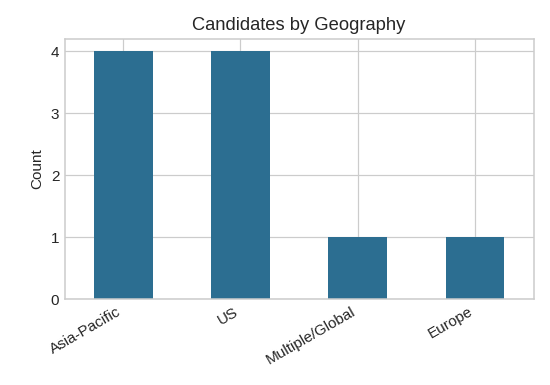

In [9]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(5,3.5))
df['geography'].value_counts().plot(kind='bar', ax=ax, color='#2C6E91')
ax.set_title('Candidates by Geography'); ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

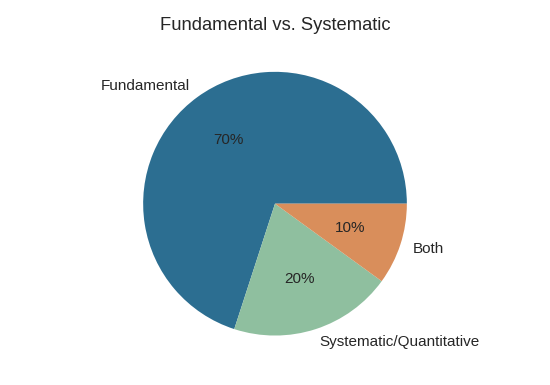

In [10]:
fig, ax = plt.subplots(figsize=(5,3.5))
vc = df['strategy_type'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.0f%%',
       colors=['#2C6E91','#8FBF9F','#D98E5B','#B25C5C'])
ax.set_title('Fundamental vs. Systematic'); plt.tight_layout(); plt.show()

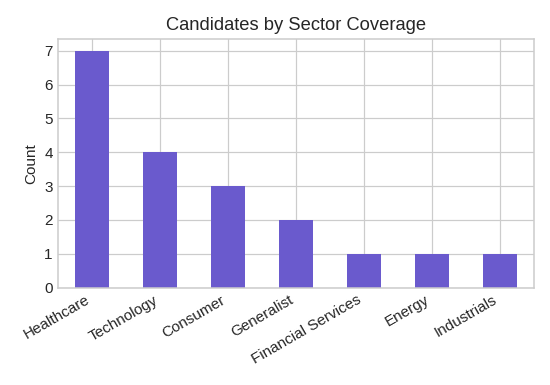

In [11]:
sectors = pd.Series([s.strip() for row in df['sectors'] for s in row.split(',')])
fig, ax = plt.subplots(figsize=(5,3.5))
sectors.value_counts().plot(kind='bar', ax=ax, color='#6A5ACD')
ax.set_title('Candidates by Sector Coverage'); ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

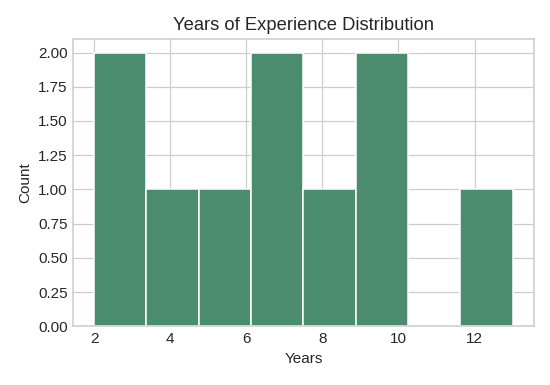

In [12]:
fig, ax = plt.subplots(figsize=(5,3.5))
ax.hist(df['total_years_experience'], bins=8, color='#4C8C6E', edgecolor='white')
ax.set_title('Years of Experience Distribution'); ax.set_xlabel('Years'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

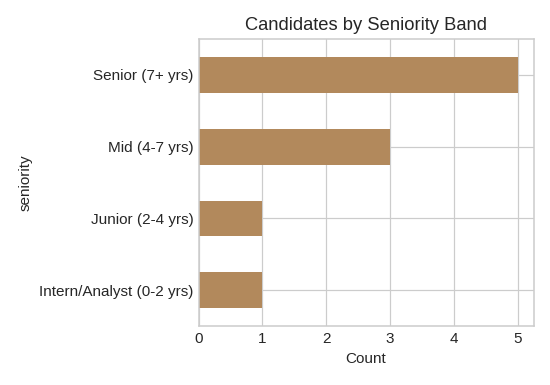

In [13]:
seniority_order = ['Intern/Analyst (0-2 yrs)', 'Junior (2-4 yrs)', 'Mid (4-7 yrs)', 'Senior (7+ yrs)']
fig, ax = plt.subplots(figsize=(5,3.5))
sc = df['seniority'].value_counts().reindex(seniority_order).dropna()
sc.plot(kind='barh', ax=ax, color='#B2895C')
ax.set_title('Candidates by Seniority Band'); ax.set_xlabel('Count')
plt.tight_layout(); plt.show()

In [14]:
print('By geography:')
print(df['geography'].value_counts(), '\n')

print('By strategy type:')
print(df['strategy_type'].value_counts(), '\n')

print('By seniority:')
print(df['seniority'].value_counts())

By geography:
geography
Asia-Pacific       4
US                 4
Multiple/Global    1
Europe             1

By strategy type:
strategy_type
Fundamental                7
Systematic/Quantitative    2
Both                       1

By seniority:
seniority
Senior (7+ yrs)             5
Mid (4-7 yrs)               3
Junior (2-4 yrs)            1
Intern/Analyst (0-2 yrs)    1

## 8. Streamlit search app (`streamlit_app.py`)

**🔗 Live app: [https://resume-search-platform-1.streamlit.app/](https://resume-search-platform-1.streamlit.app/)** — deployed on Streamlit Community Cloud.

Interactive BD-facing UI over the same `output/parsed_resumes.json`: sidebar filters for geography, strategy type, sector, seniority, years of experience, and a free-text search box (name/employer/skill/achievement); an **Insights** tab with the interactive Plotly versions of the charts above; per-candidate expandable detail cards with full work history and education; and a filtered-results CSV download.

**Run it locally instead:**
```bash
pip install -r requirements.txt
streamlit run streamlit_app.py
```

In [ ]:
"""
streamlit_app.py
-----------------
Phase 2 deliverable: BD-facing search/filter UI over the parsed candidate data.

Run locally:   streamlit run streamlit_app.py
Deploy (free): push this repo to GitHub -> https://share.streamlit.io ->
               "New app" -> point at this file. That gives a public share
               link (streamlit.app URL) without needing your own server.

Data source: reads output/parsed_resumes.json (falls back to .csv) produced
by src/llm_parser.py. Nothing in this file talks to the Anthropic API --
parsing is a separate, offline batch step (see the notebook) so the UI stays
fast and doesn't burn API spend on every filter click.
"""

from pathlib import Path
import json

import pandas as pd
import plotly.express as px
import streamlit as st

st.set_page_config(
    page_title="Candidate Search — BD Sourcing",
    page_icon="🔎",
    layout="wide",
)

DATA_DIR = (Path(__file__).parent if "__file__" in globals() else Path.cwd()) / "output"


@st.cache_data
def load_candidates() -> pd.DataFrame:
    """
    Load the parsed candidate JSON (full-fidelity) and flatten it into a
    DataFrame the UI can filter on. Cached so re-running filters doesn't
    re-read/re-parse the file on every interaction.
    """
    json_path = DATA_DIR / "parsed_resumes.json"
    if not json_path.exists():
        st.error(
            f"Couldn't find {json_path}. Run the parsing notebook first "
            "(src/llm_parser.py -> output/parsed_resumes.json)."
        )
        st.stop()

    with open(json_path) as f:
        records = json.load(f)

    rows = []
    for r in records:
        rows.append(
            {
                "full_name": r["full_name"],
                "source_file": r["source_file"],
                "geography": r["geography"],
                "strategy_type": r["strategy_type"],
                "sectors": r.get("sectors", []),
                "seniority": r["seniority"],
                "total_years_experience": r["total_years_experience"],
                "current_employer": r.get("current_employer"),
                "current_title": r.get("current_title"),
                "education": r.get("education", []),
                "certifications": r.get("certifications", []),
                "technical_skills": r.get("technical_skills", []),
                "languages": r.get("languages", []),
                "work_history": r.get("work_history", []),
                "key_achievements": r.get("key_achievements", []),
                "parse_confidence": r.get("parse_confidence", "high"),
                "parse_notes": r.get("parse_notes"),
            }
        )
    return pd.DataFrame(rows)


df = load_candidates()

st.sidebar.title("🔎 Filters")
st.sidebar.caption(f"{len(df)} candidates in the database")

if st.sidebar.button("↺ Clear all filters"):
    for key in ("search_text", "geo_filter", "strategy_filter", "sector_filter",
                "seniority_filter", "yrs_range", "cert_filter"):
        st.session_state.pop(key, None)
    st.rerun()

search_text = st.sidebar.text_input(
    "Search (name, employer, skill, achievement)",
    placeholder="e.g. Goldman, Python, CFA...",
    key="search_text",
)

all_geo = sorted(df["geography"].unique())
geo_filter = st.sidebar.multiselect("Geography", all_geo, default=all_geo, key="geo_filter")

all_strategy = sorted(df["strategy_type"].unique())
strategy_filter = st.sidebar.multiselect(
    "Strategy Type", all_strategy, default=all_strategy, key="strategy_filter"
)

all_sectors = sorted({s for row in df["sectors"] for s in row})
sector_filter = st.sidebar.multiselect("Sector", all_sectors, default=[], key="sector_filter")

seniority_order = ["Intern/Analyst (0-2 yrs)", "Junior (2-4 yrs)", "Mid (4-7 yrs)", "Senior (7+ yrs)"]
all_seniority = [s for s in seniority_order if s in df["seniority"].unique()]
seniority_filter = st.sidebar.multiselect(
    "Seniority", all_seniority, default=all_seniority, key="seniority_filter"
)

max_yrs = float(df["total_years_experience"].max())
yrs_range = st.sidebar.slider(
    "Years of experience", min_value=0.0, max_value=max(max_yrs, 1.0),
    value=(0.0, max_yrs), step=0.5, key="yrs_range",
)

cert_filter = st.sidebar.checkbox(
    "Has a professional certification (CFA/CAIA/FRM/etc.)", key="cert_filter"
)

filtered = df[
    df["geography"].isin(geo_filter)
    & df["strategy_type"].isin(strategy_filter)
    & df["seniority"].isin(seniority_filter)
    & df["total_years_experience"].between(yrs_range[0], yrs_range[1])
]

if sector_filter:
    filtered = filtered[filtered["sectors"].apply(lambda s: any(sec in s for sec in sector_filter))]

if cert_filter:
    filtered = filtered[filtered["certifications"].apply(lambda c: len(c) > 0)]

if search_text:
    q = search_text.lower()

    def matches(row) -> bool:
        haystack = " ".join(
            [
                row["full_name"],
                str(row["current_employer"] or ""),
                str(row["current_title"] or ""),
                " ".join(row["technical_skills"]),
                " ".join(row["certifications"]),
                " ".join(row["key_achievements"]),
                " ".join(e["employer"] for e in row["work_history"]),
                " ".join(e["institution"] for e in row["education"]),
                " ".join(e["degree"] for e in row["education"]),
                " ".join(row["languages"]),
            ]
        ).lower()
        return q in haystack

    filtered = filtered[filtered.apply(matches, axis=1)]

st.title("Candidate Search — BD Sourcing Platform")
st.caption(
    "Search and filter parsed analyst candidate resumes across geography, "
    "strategy type, sector, and seniority."
)

m1, m2, m3, m4 = st.columns(4)
m1.metric("Candidates matching filters", len(filtered))
m2.metric("Total candidates", len(df))
m3.metric(
    "Avg. years experience (filtered)",
    f"{filtered['total_years_experience'].mean():.1f}" if len(filtered) else "—",
)
m4.metric(
    "Systematic/Quant (filtered)",
    int((filtered["strategy_type"] == "Systematic/Quantitative").sum()) if not filtered.empty else 0,
)

if filtered.empty:
    st.warning("No candidates match the current filters. Try widening your filters above.")

tab_results, tab_insights = st.tabs(["📋 Candidates", "📊 Insights"])

with tab_results:
    if filtered.empty:
        st.warning("No candidates match the current filters.")
    else:
        sort_by = st.selectbox(
            "Sort by",
            ["Years of experience (high to low)", "Years of experience (low to high)", "Name (A-Z)"],
        )
        if sort_by.startswith("Years") and "high" in sort_by:
            filtered = filtered.sort_values("total_years_experience", ascending=False)
        elif sort_by.startswith("Years"):
            filtered = filtered.sort_values("total_years_experience", ascending=True)
        else:
            filtered = filtered.sort_values("full_name")

        for _, c in filtered.iterrows():
            with st.expander(
                f"**{c['full_name']}** — {c['current_title'] or 'N/A'} @ "
                f"{c['current_employer'] or 'N/A'}  ·  {c['total_years_experience']:.1f} yrs  ·  "
                f"{c['geography']}  ·  {c['strategy_type']}"
            ):
                col1, col2 = st.columns([2, 1])
                with col1:
                    st.markdown(f"**Sectors:** {', '.join(c['sectors']) or '—'}")
                    st.markdown(f"**Seniority:** {c['seniority']}")
                    st.markdown(f"**Certifications:** {', '.join(c['certifications']) or '—'}")
                    st.markdown(f"**Technical skills:** {', '.join(c['technical_skills']) or '—'}")
                    if c["key_achievements"]:
                        st.markdown("**Key achievements:**")
                        for a in c["key_achievements"]:
                            st.markdown(f"- {a}")
                    if c["work_history"]:
                        st.markdown("**Work history:**")
                        for job in c["work_history"]:
                            dates = f"{job.get('start_date') or '?'} – {job.get('end_date') or '?'}"
                            st.markdown(f"- **{job['title']}**, {job['employer']} ({dates})")
                with col2:
                    if c["education"]:
                        st.markdown("**Education:**")
                        for e in c["education"]:
                            st.markdown(f"- {e['degree']}, {e['institution']} ({e.get('graduation_year') or '?'})")
                    if c["parse_confidence"] != "high":
                        st.caption(f"⚠️ Parse confidence: {c['parse_confidence']}")
                        if c["parse_notes"]:
                            st.caption(c["parse_notes"])

        export_df = filtered.copy()
        export_df["sectors"] = export_df["sectors"].apply(lambda v: "; ".join(v))
        export_df["certifications"] = export_df["certifications"].apply(lambda v: "; ".join(v))
        export_df["technical_skills"] = export_df["technical_skills"].apply(lambda v: "; ".join(v))
        export_df["languages"] = export_df["languages"].apply(lambda v: "; ".join(v))
        export_df["education"] = export_df["education"].apply(
            lambda v: "; ".join(f"{e['degree']} @ {e['institution']}" for e in v)
        )
        export_df = export_df.drop(columns=["work_history", "key_achievements"])

        st.download_button(
            "⬇️ Download filtered results (CSV)",
            export_df.to_csv(index=False),
            file_name="filtered_candidates.csv",
            mime="text/csv",
        )

with tab_insights:
    scope = st.radio(
        "Show insights for:",
        ["All candidates", "Filtered candidates only"],
        horizontal=True,
        key="insights_scope",
    )
    chart_df = df if scope == "All candidates" else filtered

    if chart_df.empty:
        st.warning("No candidates to show — your current filters return zero results.")
    else:
        st.subheader(
            "Candidate pool distribution (all candidates)"
            if scope == "All candidates"
            else f"Candidate pool distribution ({len(chart_df)} filtered candidates)"
        )

        c1, c2 = st.columns(2)
        with c1:
            geo_counts = chart_df["geography"].value_counts().reset_index()
            geo_counts.columns = ["geography", "count"]
            fig = px.bar(geo_counts, x="geography", y="count", title="Candidates by Geography")
            st.plotly_chart(fig, use_container_width=True)

        with c2:
            strat_counts = chart_df["strategy_type"].value_counts().reset_index()
            strat_counts.columns = ["strategy_type", "count"]
            fig = px.pie(strat_counts, names="strategy_type", values="count", title="Fundamental vs. Systematic")
            st.plotly_chart(fig, use_container_width=True)

        c3, c4 = st.columns(2)
        with c3:
            sector_counts = pd.Series(
                [s for row in chart_df["sectors"] for s in row]
            ).value_counts().reset_index()
            sector_counts.columns = ["sector", "count"]
            fig = px.bar(sector_counts, x="sector", y="count", title="Candidates by Sector Coverage")
            st.plotly_chart(fig, use_container_width=True)

        with c4:
            fig = px.histogram(
                chart_df, x="total_years_experience", nbins=8,
                title="Years of Experience Distribution",
            )
            st.plotly_chart(fig, use_container_width=True)

        st.subheader("Seniority mix")
        sen_counts = chart_df["seniority"].value_counts().reindex(seniority_order).dropna().reset_index()
        sen_counts.columns = ["seniority", "count"]
        fig = px.bar(sen_counts, x="seniority", y="count", title="Candidates by Seniority Band")
        st.plotly_chart(fig, use_container_width=True)

st.divider()
st.caption(
    "Data parsed from resume PDFs/DOCX via the Anthropic API (see the notebook's "
    "src/llm_parser.py). Built for a 10-candidate sample — see notebook Section 8 "
    "for how this scales to thousands of resumes."
)


## 9. What I'd add with more time

**More robust parsing**
- Multi-pass extraction: a first pass for structured fields, a second, cheaper pass specifically for `parse_confidence` scoring and cross-field consistency checks (e.g. does `total_years_experience` actually match the sum of `work_history` date ranges?).
- OCR fallback (e.g. via a vision-capable Claude call on rendered page images) for scanned/image-based PDF resumes, which `pdfplumber` alone can't read.
- A small labeled eval set (20-30 resumes with human-verified fields) to actually measure parsing accuracy per field, rather than relying on spot-checks.

**Search & matching**
- Semantic/embedding-based search on top of the keyword filters, so a BD user can type "someone like our Coatue healthcare analyst but based in Europe" and get ranked matches, not just exact filter hits.
- Duplicate-candidate detection (same person, resume submitted twice or via two recruiters) via name + employer-history fuzzy matching.
- "Similar candidates" recommendations on a candidate's detail view.

**Product / workflow**
- Recruiter/BD notes and status tracking (contacted, interviewing, passed) attached to each candidate record, not just static resume data.
- Role-based access — e.g. hiring managers see only candidates tagged to their desk/strategy.
- Audit trail: who searched/viewed which candidate, for compliance in a regulated environment.

**Data pipeline (scale)** — see Section 10 below for the full breakdown; headline items are async/parallel parsing, a real database instead of flat files, event-driven ingestion on upload, and a human-review queue for low-confidence parses.

**Evaluation of business value**
- Track time-to-shortlist before/after the tool, and search-to-placement conversion, to actually quantify the BD team's time savings rather than assuming it.

## 10. Design for scalability — notes

This sample runs 10 resumes sequentially in a notebook. At the volume a real BD pipeline would see (hundreds to thousands of resumes/month), the plan is:

- **Parallelize parsing**: swap the sequential loop in `parse_resume_batch` for an async client (`anthropic.AsyncAnthropic`) behind a semaphore, or push files onto a queue (SQS/Celery) consumed by a small worker pool — keeps per-file latency the same while raising throughput.
- **Idempotent storage**: parsed output should land in a database (e.g. Postgres with a JSONB column mirroring `CandidateProfile`, plus indexed columns for the headline filters) instead of flat JSON/CSV files, keyed on a content hash of the source file so re-uploads don't re-parse or duplicate.
- **Incremental ingestion**: new resumes get parsed on upload (event-driven), not in a nightly full-batch re-run.
- **Cost/latency control**: cache raw-text extraction separately from the LLM call so a schema change doesn't require re-extracting text; consider a cheaper/faster model tier for high-volume ingestion, with the current model reserved for a periodic re-validation pass.
- **Human-in-the-loop review**: route any record with `parse_confidence != "high"` (or a non-empty `parse_notes`) to a lightweight review queue rather than trusting it silently — 4 of the 10 sample resumes hit this (ambiguous/relative dates, mixed fundamental/quant signal, missing contact info), and that ratio will only grow with messier real-world resumes.
- **Streamlit at scale**: `st.cache_data` already avoids re-reading the file on every filter click; beyond a few thousand candidates, swap the JSON-file read for a direct (indexed) database query so the app doesn't load the entire candidate pool into memory per session.